#Lbreria SDV
#autor: obed capistran velazquez
#fecha: 04 de junio 

In [4]:
import pandas as pd 
import numpy as np
import random 

In [10]:
%pip install sdv

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 2.19.0 requires botocore<1.36.4,>=1.36.0, but you have botocore 1.43.23 which is incompatible.



  Using cached sdv-1.37.0-py3-none-any.whl.metadata (14 kB)
  Using cached boto3-1.43.23-py3-none-any.whl.metadata (6.6 kB)
  Using cached copulas-0.14.1-py3-none-any.whl.metadata (9.7 kB)
  Using cached ctgan-0.12.1-py3-none-any.whl.metadata (10 kB)
  Using cached deepecho-0.8.1-py3-none-any.whl.metadata (11 kB)
  Using cached rdt-1.21.0-py3-none-any.whl.metadata (11 kB)
  Using cached sdmetrics-0.28.0-py3-none-any.whl.metadata (9.9 kB)
  Using cached botocore-1.43.23-py3-none-any.whl.metadata (5.6 kB)
  Using cached s3transfer-0.18.0-py3-none-any.whl.metadata (1.7 kB)
Using cached sdv-1.37.0-py3-none-any.whl (206 kB)
Using cached boto3-1.43.23-py3-none-any.whl (140 kB)
Using cached botocore-1.43.23-py3-none-any.whl (15.1 MB)
Using cached s3transfer-0.18.0-py3-none-any.whl (88 kB)
Using cached copulas-0.14.1-py3-none-any.whl (52 kB)
Using cached ctgan-0.12.1-py3-none-any.whl (25 kB)
Using cached deepecho-0.8.1-py3-none-any.whl (28 kB)
Using cached rdt-1.21.0-py3-none-any.whl (74 kB)


In [11]:
import sdv 
import sdmetrics 
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [14]:
from sdmetrics.reports.single_table import QualityReport

In [15]:
#cramos un datset para crear los datos sinteticos 

dfClientes = pd.DataFrame(
    {
        "cliente_id" : [1,2,3,4,5,6,7,8,9,10],
        "edad": [23,33,43,28,53,56,43,56,65,40],
        "ingreso_mensual":[25000,15000,2000,1000,5000,17000,30000,7500,4555,12200],
        "ciudad": ["Veracuez","Cordoba","paso del macho","amatlan","fortin", "cuihitlahuac","cordoba","orisaba","yanga","carrillo"]
        
    }
)


In [16]:
dfClientes.head()

,cliente_id,edad,ingreso_mensual,ciudad
0,1,23,25000,Veracuez
1,2,33,15000,Cordoba
2,3,43,2000,paso del macho
3,4,28,1000,amatlan
4,5,53,5000,fortin


In [17]:
metadata = SingleTableMetadata()

In [18]:
metadata.detect_from_dataframe(
    data= dfClientes
)


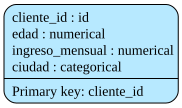

In [19]:
#instalar el completo graphviz (URL)
metadata.visualize() 

In [20]:
metadata.to_dict()

{'primary_key': 'cliente_id',
 'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}},
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}

In [21]:
#guardar los metadatos en archivo json
metadata.save_to_json(
    "dfClientes_metadata.json"
)

In [22]:
#entrenamos los modelos 
synthesizer = GaussianCopulaSynthesizer(
    metadata
)

C:\Users\prueb\anaconda3\Lib\site-packages\sdv\single_table\base.py:182: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


In [23]:
#entrenamiento 
synthesizer.fit(
    dfClientes
)

In [24]:
#generar los datos sinteticos 
clientes_sinteticos = synthesizer.sample (
    num_rows=100
)

In [25]:
clientes_sinteticos.head()

,cliente_id,edad,ingreso_mensual,ciudad
0,16169768,60,12232,carrillo
1,4918803,36,26566,cordoba
2,1900081,35,14338,yanga
3,531516,29,24390,yanga
4,10211768,49,25722,yanga


In [26]:
clientes_sinteticos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cliente_id       100 non-null    int64 
 1   edad             100 non-null    int64 
 2   ingreso_mensual  100 non-null    int64 
 3   ciudad           100 non-null    object
dtypes: int64(3), object(1)
memory usage: 3.3+ KB


In [27]:
clientes_sinteticos.describe(include="all")

,cliente_id,edad,ingreso_mensual,ciudad
count,1.000000e+02,100.000000,100.000000,100
unique,NaN,NaN,NaN,10
top,NaN,NaN,NaN,carrillo
freq,NaN,NaN,NaN,21
mean,8.532170e+06,43.140000,15590.710000,NaN
std,4.687773e+06,12.044547,8772.333088,NaN
min,4.660500e+04,28.000000,1582.000000,NaN
25%,5.008268e+06,33.000000,7699.250000,NaN
50%,8.656048e+06,41.000000,14344.000000,NaN
75%,1.256688e+07,53.250000,24575.500000,NaN


In [28]:
#dataframe contaminado
dfClientesGIGO= clientes_sinteticos.copy()

In [29]:
#colocar edades 
indices = random.sample(list(dfClientesGIGO.index),5)

In [30]:
dfClientesGIGO.loc[indices,"edad"]-5

55    23
63    49
84    49
56    40
8     57
Name: edad, dtype: int64

In [31]:
#introducir valores duplicados 
duplicados = dfClientesGIGO.sample(10,random_state=42)

In [32]:
dfClientesGIGO = pd.concat([dfClientesGIGO,duplicados], ignore_index=True)

In [33]:
dfClientesGIGO .duplicated().sum()

np.int64(10)

In [34]:
dfClientesGIGO.describe(include="all")

,cliente_id,edad,ingreso_mensual,ciudad
count,1.100000e+02,110.000000,110.000000,110
unique,NaN,NaN,NaN,10
top,NaN,NaN,NaN,carrillo
freq,NaN,NaN,NaN,22
mean,8.614045e+06,42.372727,15110.918182,NaN
std,4.775996e+06,12.085217,8766.652699,NaN
min,4.660500e+04,28.000000,1582.000000,NaN
25%,4.948624e+06,32.000000,7234.000000,NaN
50%,8.956428e+06,40.000000,12908.000000,NaN
75%,1.274153e+07,52.750000,23650.000000,NaN


In [35]:
reporte = QualityReport()

In [36]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data=clientes_sinteticos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████████████████████████████████████████████████| 4/4 [00:00<00:00, 174.21it/s]|
Column Shapes Score: 78.0%

(2/2) Evaluating Column Pair Trends: |██████████████████████████████████████████████████| 6/6 [00:00<00:00, 66.81it/s]|
Column Pair Trends Score: 8.5%

Overall Score (Average): 43.25%



In [37]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data=dfClientesGIGO,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████████████████████████████████████████████████| 4/4 [00:00<00:00, 316.31it/s]|
Column Shapes Score: 78.18%

(2/2) Evaluating Column Pair Trends: |██████████████████████████████████████████████████| 6/6 [00:00<00:00, 77.86it/s]|
Column Pair Trends Score: 9.09%

Overall Score (Average): 43.64%

